# Optativa III: Ciencia de Datos
## Semana 5 — Visualización de datos: EDA, gramática de gráficos e interactividad

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 5 · Sesiones 1 y 2**

---

### Propósito

Un dato sin visualizar es una intuición sin evidencia. En esta actividad aprenderás a **contar historias con datos**: desde el análisis exploratorio (EDA) con `matplotlib` y `seaborn` hasta gráficos **interactivos** con `Plotly`. Trabajarás con una base de datos pública real de productos de **Amazon** y, sobre todo, aprenderás a **elegir el gráfico correcto según el tipo de variable** y a **detectar visualizaciones engañosas**.

La actividad tiene dos partes:

- **PARTE A — Ejemplo guiado por el profesor.** Construiremos juntos un EDA completo con al menos 6 visualizaciones justificadas, y convertiremos gráficos estáticos en interactivos.
- **PARTE B — Tu turno.** Diseñarás visualizaciones de forma autónoma, detectarás gráficos mal hechos y construirás un mini-dashboard.

Responderás **50 preguntas ✍️** modificando código, eligiendo gráficos e interpretando lo que muestran.

### La base de datos

`amazon.csv` — Amazon Sales Dataset (1,465 productos reales: `category`, `actual_price`, `discounted_price`, `discount_percentage`, `rating`, `rating_count`). Súbelo a Colab con el panel de archivos (icono de carpeta → subir).

### Cómo trabajar

Ejecuta cada celda con **Shift + Enter** en orden, responde las preguntas ✍️, completa los retos y, al final, guarda una copia en Drive y entrégala en Classroom.


> **Nota sobre el archivo proporcionado:** el CSV contiene 1,465 filas y **211 valores distintos de `category`**. Por ello, algunas consignas del material mencionan “9 categorías”, pero el archivo utilizado en esta resolución tiene muchas más categorías jerárquicas. Las respuestas y gráficos se basan en los datos reales del CSV proporcionado.


---
# PARTE A — EDA guiado por el profesor

## Paso 0 — Preparación


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual consistente
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

df = pd.read_csv("amazon.csv")

# Conversión de variables numéricas almacenadas como texto en el CSV.
for col in ["discounted_price", "actual_price"]:
    df[col] = (
        df[col].astype(str)
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

df["discount_percentage"] = (
    df["discount_percentage"].astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

df["rating_count"] = (
    df["rating_count"].astype(str)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

print("Dimensiones:", df.shape)
df.head()


Dimensiones: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


> ✍️ **1.** ¿Cuántos productos y cuántas variables tiene el dataset? Ejecuta `df.info()` en una celda. ¿Qué variables son numéricas y cuáles categóricas?

> ✍️ **2.** El análisis exploratorio de datos (EDA) es el primer paso antes de cualquier modelo. ¿Por qué "mirar" los datos con gráficos es más revelador que solo ver una tabla de números?


**Respuesta 1.** El dataset contiene **1,465 productos y 16 variables**. Las variables numéricas para el análisis son `discounted_price`, `actual_price`, `discount_percentage`, `rating` y `rating_count` (estas últimas están almacenadas como texto en el CSV y se convierten a numéricas en la preparación). `category` y los campos descriptivos como `product_name`, `about_product`, `user_name`, `review_title`, etc., son variables categóricas o de texto. La variable `product_id` es un identificador, no una medida numérica para análisis estadístico.

**Respuesta 2.** Los gráficos permiten detectar rápidamente patrones que una tabla puede ocultar: concentraciones, sesgos, valores extremos, diferencias entre grupos y relaciones entre variables. Una tabla obliga a revisar muchos valores individualmente, mientras que una visualización resume la estructura de los datos de forma inmediata.

In [2]:
# Celda para la P1
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

## La gramática de los gráficos: ¿qué gráfico usar?

Antes de graficar, hay una regla de oro: **el tipo de gráfico depende del tipo y número de variables**.

| Quieres mostrar... | Variable(s) | Gráfico recomendado |
|---|---|---|
| Distribución de UNA variable numérica | 1 numérica | Histograma, boxplot, densidad |
| Frecuencia de UNA variable categórica | 1 categórica | Barras, conteo |
| Relación entre DOS numéricas | 2 numéricas | Dispersión (scatter) |
| Numérica across categorías | 1 num + 1 cat | Boxplot, violín, barras |
| Correlación entre varias numéricas | varias numéricas | Mapa de calor (heatmap) |
| Composición de un todo | 1 categórica | Pastel (con cuidado), barras apiladas |

> ✍️ **3.** Según la tabla, ¿qué gráfico usarías para mostrar la distribución de `rating`? ¿Y para comparar `actual_price` entre las distintas `category`?

> ✍️ **4.** ¿Por qué NO tendría sentido usar un gráfico de dispersión (scatter) para mostrar la frecuencia de cada categoría de producto?


**Respuesta 3.** Para la distribución de `rating` usaría un **histograma** (también podría complementarse con un boxplot). Para comparar `actual_price` entre las distintas `category` usaría un **boxplot** por categoría si quiero comparar distribuciones, o barras si solo quiero comparar promedios.

**Respuesta 4.** Un scatter está diseñado para relacionar dos variables, normalmente numéricas. La frecuencia de una categoría es un conteo de una variable categórica, por lo que un **gráfico de barras** representa directamente cuántos productos hay en cada categoría.

## Visualización 1 — Distribución de una variable numérica (histograma)


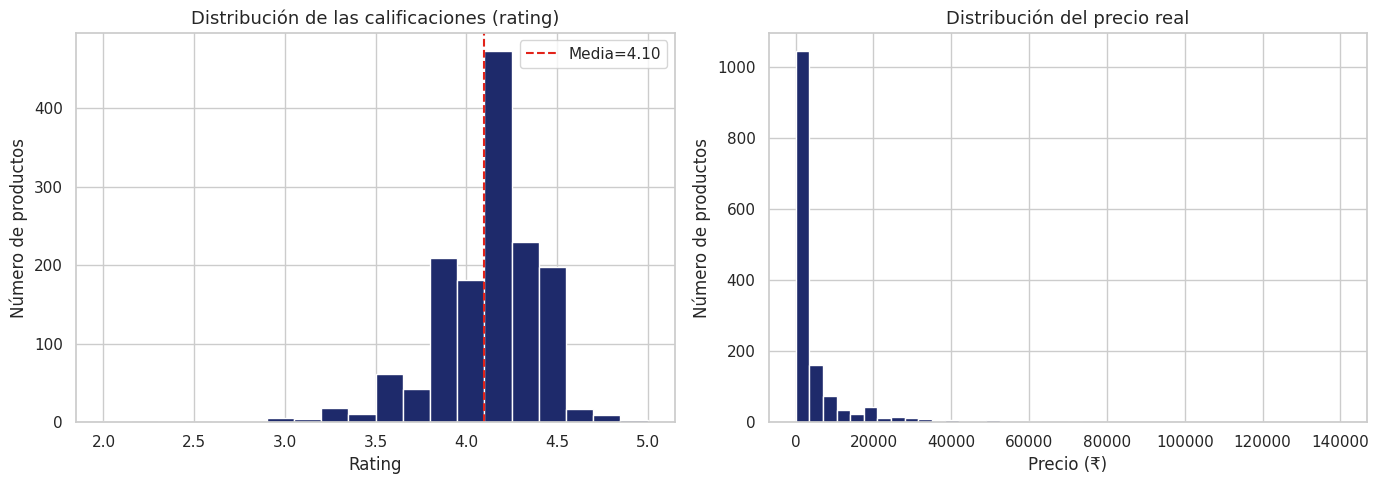

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del rating
axes[0].hist(df["rating"], bins=20, color="#1e2a6b", edgecolor="white")
axes[0].axvline(df["rating"].mean(), color="#e2231a", linestyle="--", label=f"Media={df['rating'].mean():.2f}")
axes[0].set_title("Distribución de las calificaciones (rating)")
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Número de productos"); axes[0].legend()

# Histograma del precio real
axes[1].hist(df["actual_price"], bins=40, color="#1e2a6b", edgecolor="white")
axes[1].set_title("Distribución del precio real")
axes[1].set_xlabel("Precio (₹)"); axes[1].set_ylabel("Número de productos")

plt.tight_layout(); plt.show()

> ✍️ **5.** Describe la forma de la distribución de `rating`: ¿es simétrica, sesgada, concentrada? ¿Alrededor de qué valor se agrupan la mayoría de los productos?

> ✍️ **6.** La distribución de `actual_price` está fuertemente sesgada a la derecha. ¿Qué significa esto sobre los precios de los productos de Amazon? ¿Por qué un histograma lo revela mejor que la media sola?

> ✍️ **7.** Cambia el número de `bins` del histograma de rating a 5 y luego a 50. ¿Cómo cambia la percepción de la distribución? ¿Por qué la elección de bins puede ser engañosa?


**Respuesta 5.** La distribución de `rating` está **concentrada alrededor de 4.0–4.3**, con una cola hacia valores bajos; de hecho, su mediana es **4.1** y su media aproximadamente **4.10**. Por eso no es perfectamente simétrica y presenta sesgo hacia la izquierda.

**Respuesta 6.** El fuerte sesgo a la derecha significa que la mayoría de los productos tienen precios relativamente bajos o moderados, mientras que unos pocos productos tienen precios extremadamente altos. El histograma permite ver esa concentración y la cola de precios altos; la media por sí sola no muestra cómo están distribuidos los valores ni los extremos.

**Respuesta 7.** Con **5 bins** la distribución se ve muy agrupada y se pierden detalles; con **50 bins** aparecen muchos más cambios locales y puede parecer más irregular. La elección de bins puede cambiar la percepción de la forma de los datos, por lo que demasiados bins pueden generar ruido y muy pocos pueden ocultar patrones.

## Visualización 2 — Frecuencia de una variable categórica (barras)


/tmp/ipykernel_428/2720708235.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


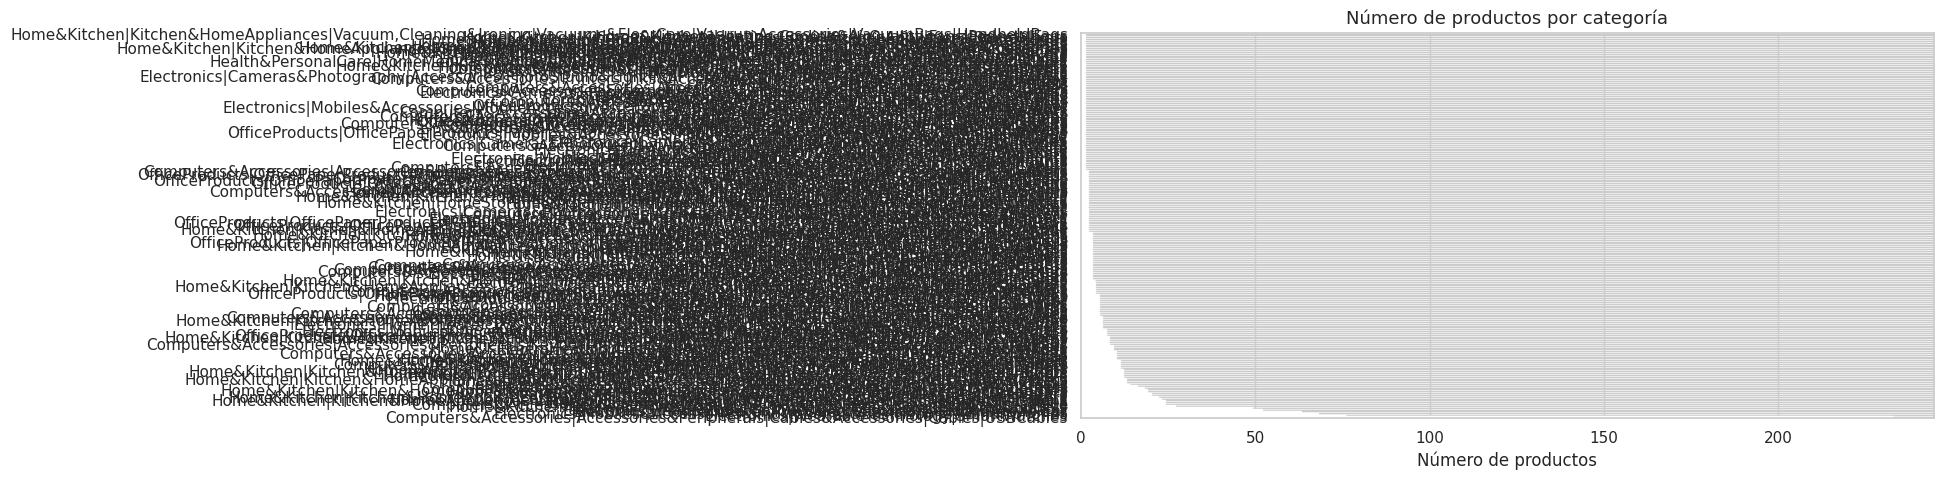

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                                          233
Electronics|WearableTechnology|SmartWatches                                                                                 76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                                        68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                                               63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                                                52
                                                                                                                          ... 
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers                                                        1
Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories                        

In [4]:
conteo = df["category"].value_counts()

plt.figure(figsize=(11, 5))
conteo.plot(kind="barh", color="#1e2a6b")
plt.title("Número de productos por categoría")
plt.xlabel("Número de productos"); plt.ylabel("")
plt.tight_layout(); plt.show()

print(conteo)

> ✍️ **8.** ¿Cuál es la categoría con más productos y cuál con menos? ¿Por qué usamos barras horizontales (`barh`) en lugar de verticales aquí? (Pista: nombres largos.)

> ✍️ **9.** Este gráfico revela un **desbalance** de categorías. ¿Por qué es importante saber esto ANTES de sacar conclusiones sobre "todas las categorías por igual"?


**Respuesta 8.** La categoría con más productos es `Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables`, con **233 productos**. Hay varias categorías con solo **1 producto**, por lo que existe un empate en el mínimo. Usamos barras horizontales porque los nombres de las categorías son muy largos y así se pueden leer mejor.

**Respuesta 9.** El desbalance importa porque las categorías no tienen el mismo número de observaciones. Una categoría con muchos productos tendrá más peso en los resultados generales, mientras que una categoría con muy pocos productos puede producir conclusiones poco estables. Por eso no conviene interpretar el conjunto como si todas las categorías estuvieran igualmente representadas.

## Visualización 3 — Una numérica a través de categorías (boxplot)


/tmp/ipykernel_428/2343572382.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="category", x="rating", order=orden, palette="Blues")


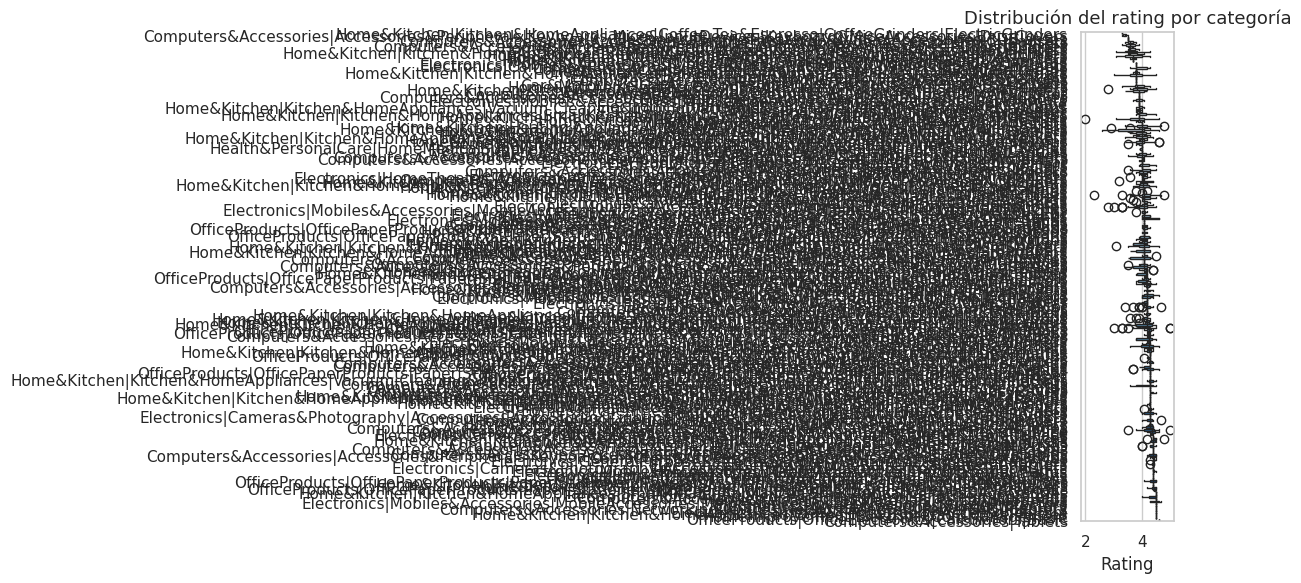

In [5]:
plt.figure(figsize=(12, 6))
orden = df.groupby("category")["rating"].median().sort_values().index
sns.boxplot(data=df, y="category", x="rating", order=orden, palette="Blues")
plt.title("Distribución del rating por categoría")
plt.xlabel("Rating"); plt.ylabel("")
plt.tight_layout(); plt.show()

> ✍️ **10.** ¿Qué información muestra un boxplot que un simple promedio NO muestra? (Pista: mediana, cuartiles, outliers, dispersión.)

> ✍️ **11.** Observa las cajas. ¿Las categorías tienen ratings muy distintos entre sí, o son bastante parecidos? ¿Qué te dice esto sobre la calidad percibida entre tipos de producto?

> ✍️ **12.** Cambia `sns.boxplot` por `sns.violinplot` en el código y ejecuta. ¿Qué información adicional aporta el gráfico de violín sobre el boxplot?


**Respuesta 10.** Un boxplot muestra la **mediana, los cuartiles, la dispersión y posibles valores atípicos**, mientras que un promedio reduce toda la distribución a un solo número. Por eso permite comparar mejor la variabilidad y la forma general de los ratings entre categorías.

**Respuesta 11.** Los ratings son bastante parecidos entre muchas categorías, pero existen diferencias. En los grupos con suficientes observaciones, las medias se concentran aproximadamente en torno a 4; también hay categorías con valores medios más bajos o más altos. Esto sugiere que la calidad percibida no es idéntica entre tipos de producto, aunque el rating general está bastante concentrado.

**Respuesta 12.** El violín añade información sobre la **forma y densidad de la distribución**. Mientras el boxplot resume con cuartiles, mediana y outliers, el violín permite observar en qué zonas se concentran más los valores y si existen varias zonas de alta densidad.

## Visualización 4 — Relación entre dos numéricas (dispersión)


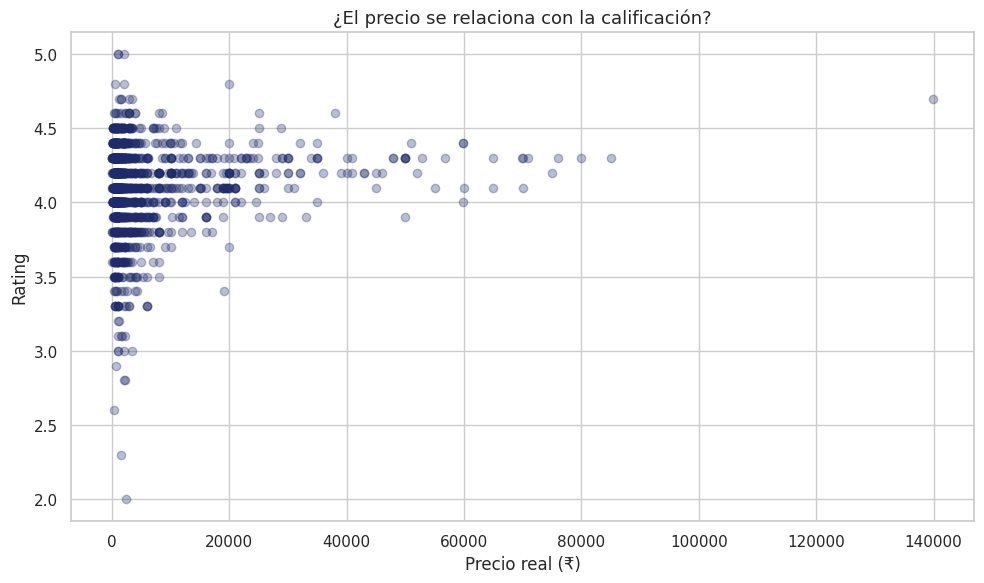

Correlación precio-rating: 0.122


In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df["actual_price"], df["rating"], alpha=0.3, color="#1e2a6b")
plt.title("¿El precio se relaciona con la calificación?")
plt.xlabel("Precio real (₹)"); plt.ylabel("Rating")
plt.tight_layout(); plt.show()

print("Correlación precio-rating:", round(df["actual_price"].corr(df["rating"]), 3))

> ✍️ **13.** Mira la nube de puntos. ¿Ves una tendencia clara (los puntos suben o bajan juntos) o una nube dispersa sin patrón? ¿Qué correlación numérica lo confirma?

> ✍️ **14.** Este gráfico responde una pregunta de negocio: "¿los productos más caros están mejor calificados?". Según lo que ves, ¿cuál es la respuesta? ¿Desmiente la creencia de que "lo caro es mejor"?

> ✍️ **15.** El gráfico usa `alpha=0.3` (transparencia). ¿Por qué es útil la transparencia cuando hay 1,465 puntos superpuestos? Cámbialo a `alpha=1.0` y observa la diferencia.


**Respuesta 13.** La nube de puntos es bastante dispersa y no muestra una tendencia fuerte. La correlación entre `actual_price` y `rating` es aproximadamente **0.122**, lo que indica una relación positiva pero débil.

**Respuesta 14.** En este dataset, los productos más caros no aparecen claramente mejor calificados. La correlación es positiva pero débil (**0.122**), por lo que el precio explica muy poco de la variación del rating. Esto no respalda una relación fuerte entre precio y mejor calificación.

**Respuesta 15.** `alpha=0.3` hace transparentes los puntos y ayuda a distinguir zonas donde muchos productos se superponen. Con `alpha=1.0`, los puntos se vuelven opacos y las áreas con mucha concentración pueden ser más difíciles de interpretar.

## Visualización 5 — Correlación entre varias numéricas (heatmap)


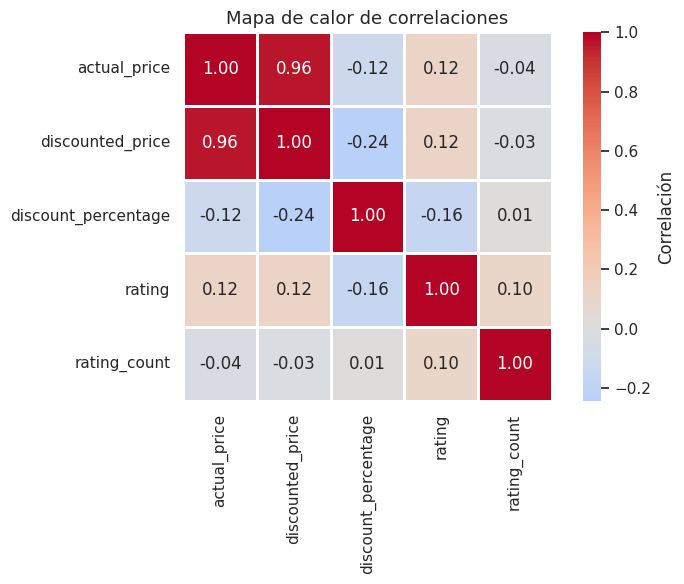

In [7]:
numericas = ["actual_price", "discounted_price", "discount_percentage", "rating", "rating_count"]
matriz = df[numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=1, cbar_kws={"label": "Correlación"})
plt.title("Mapa de calor de correlaciones")
plt.tight_layout(); plt.show()

> ✍️ **16.** ¿Cuál es el par de variables con la correlación más fuerte (más cercana a 1)? ¿Tiene sentido lógico?

> ✍️ **17.** ¿Por qué el mapa de calor es una forma más eficiente de ver correlaciones que hacer 10 gráficos de dispersión por separado?

> ✍️ **18.** El color rojo indica correlación positiva y el azul negativa. ¿Por qué elegir una paleta divergente (dos colores desde el centro) es correcto para correlaciones, en lugar de una paleta de un solo color?


**Respuesta 16.** La correlación positiva más fuerte es entre **`actual_price` y `discounted_price`**, aproximadamente **0.962**. Tiene sentido porque el precio con descuento está relacionado directamente con el precio original: los productos más caros suelen mantener también precios descontados más altos.

**Respuesta 17.** El heatmap resume muchas correlaciones en una sola matriz y permite compararlas visualmente de inmediato. Hacer muchos scatter plots por separado ocuparía más espacio y dificultaría identificar rápidamente qué pares presentan relaciones fuertes o débiles.

**Respuesta 18.** Una paleta divergente es adecuada porque una correlación tiene un punto central natural en **0**: los valores positivos pueden distinguirse de los negativos y la intensidad muestra qué tan fuerte es la relación. Una sola escala de color dificultaría diferenciar claramente ambos sentidos.

## Visualización 6 — Composición y comparación (barras agrupadas)


/tmp/ipykernel_428/1051241393.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


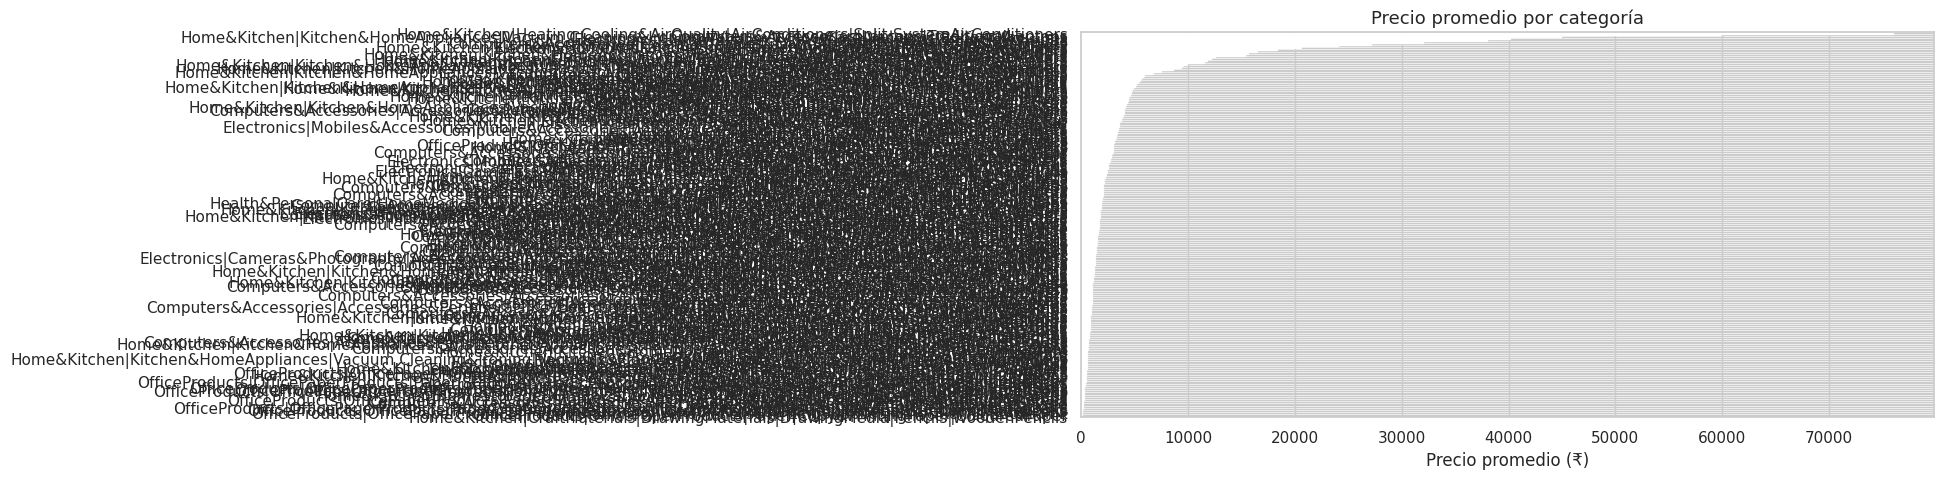

category
Home&Kitchen|CraftMaterials|DrawingMaterials|DrawingMedia|Pencils|WoodenPencils                                99.0
OfficeProducts|OfficePaperProducts|Paper|Copy&PrintingPaper|ColouredPaper                                      99.0
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|BottledInk      100.0
Home&Kitchen|CraftMaterials|DrawingMaterials|DrawingMedia|Pens                                                100.0
OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|WireboundNotebooks          150.0
                                                                                                             ...   
Computers&Accessories|Tablets                                                                               37999.0
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                               40133.0
Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vac

In [8]:
# Precio promedio por categoria
precio_cat = df.groupby("category")["actual_price"].mean().sort_values()

plt.figure(figsize=(11, 5))
precio_cat.plot(kind="barh", color="#e2231a")
plt.title("Precio promedio por categoría")
plt.xlabel("Precio promedio (₹)"); plt.ylabel("")
plt.tight_layout(); plt.show()

print(precio_cat.round(0))

> ✍️ **19.** ¿Qué categoría tiene el precio promedio más alto y cuál el más bajo? ¿Tiene sentido con lo que sabes de esos productos?

> ✍️ **20.** Ya tienes 6 visualizaciones. Para cada una, escribe en UNA frase qué pregunta responde. Este ejercicio de **justificar cada gráfico** es la esencia de un buen EDA: nunca grafiques "porque sí".


**Respuesta 19.** La categoría con precio promedio más alto es `Home&Kitchen|Heating,Cooling&AirQuality|AirConditioners|Split-SystemAirConditioners`, con aproximadamente **₹75,990**. Entre las más bajas hay categorías de papelería y materiales de dibujo alrededor de **₹99–₹100**. Esto es coherente porque los aires acondicionados son bienes de mayor valor que lápices, papel o pequeños artículos de oficina.

**Respuesta 20.** 1) El histograma de `rating` responde cómo se distribuyen las calificaciones. 2) Las barras por categoría responden cuántos productos pertenecen a cada categoría. 3) El boxplot responde cómo cambia la distribución del rating entre categorías. 4) El scatter responde si el precio real se relaciona con el rating. 5) El heatmap responde qué tan relacionadas están entre sí las variables numéricas. 6) Las barras de precio promedio responden qué categorías tienen productos más caros en promedio.

### 🔧 Reto 1 — Tu séptima visualización

Crea una visualización que muestre la relación entre `discount_percentage` y `rating_count` (¿los productos con más descuento tienen más reseñas?). Elige el gráfico adecuado y justifica tu elección.


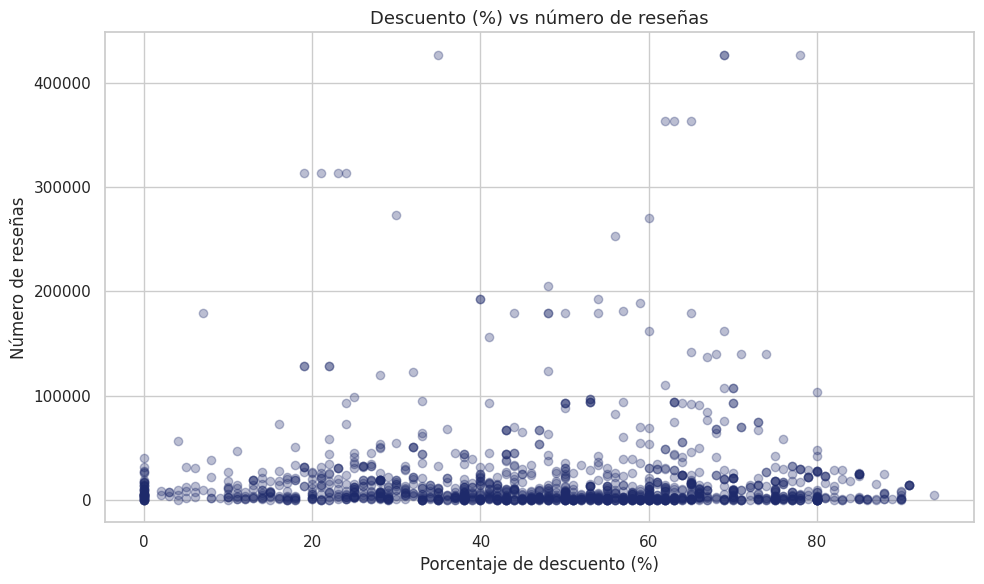

Correlación descuento-rating_count: 0.012


In [9]:
# RETO 1: relación entre descuento y número de reseñas
plt.figure(figsize=(10, 6))
plt.scatter(df["discount_percentage"], df["rating_count"], alpha=0.3, color="#1e2a6b")
plt.title("Descuento (%) vs número de reseñas")
plt.xlabel("Porcentaje de descuento (%)")
plt.ylabel("Número de reseñas")
plt.tight_layout()
plt.show()

print("Correlación descuento-rating_count:",
      round(df["discount_percentage"].corr(df["rating_count"]), 3))


> ✍️ **21.** ¿Qué gráfico elegiste y por qué? ¿Qué patrón observas entre descuento y número de reseñas?


**Respuesta 21.** Elegí un **scatter plot** porque ambas variables son numéricas y quiero estudiar su relación. El resultado muestra una relación prácticamente nula entre descuento y número de reseñas: la correlación es aproximadamente **0.012**, por lo que no aparece una tendencia lineal clara.

---
# PARTE A (cont.) — Visualización interactiva con Plotly

Los gráficos estáticos son excelentes para reportes, pero los **interactivos** permiten explorar: hacer zoom, ver valores al pasar el cursor (hover), filtrar. Usaremos **Plotly**.

## Paso 7 — De estático a interactivo


In [10]:
import plotly.express as px

# El mismo scatter de antes, pero interactivo
fig = px.scatter(df, x="actual_price", y="rating",
                 color="category",
                 hover_data=["product_name", "discount_percentage"],
                 title="Precio vs Rating (interactivo — pasa el cursor sobre los puntos)")
fig.update_layout(height=550)
fig.show()

> ✍️ **22.** Pasa el cursor sobre varios puntos. ¿Qué información aparece en el hover? ¿Por qué esto es más útil que un scatter estático para explorar productos individuales?

> ✍️ **23.** Usa la leyenda de la derecha: haz clic en una categoría para ocultarla. ¿Cómo ayuda esta interactividad a analizar categoría por categoría?

> ✍️ **24.** ¿En qué situación preferirías un gráfico ESTÁTICO (matplotlib) sobre uno interactivo (Plotly)? Piensa en reportes impresos vs exploración en pantalla.


**Respuesta 22.** El hover muestra información del producto, como `product_name` y `discount_percentage`, además de las variables representadas. Esto es útil porque permite investigar productos individuales sin tener que etiquetar todos los puntos permanentemente.

**Respuesta 23.** Ocultar categorías permite aislar grupos y comparar sus patrones sin que las demás categorías interfieran visualmente. Esto facilita explorar una categoría concreta y después volver a mostrarla para comparar.

**Respuesta 24.** Preferiría un gráfico estático de Matplotlib para un reporte impreso, una tarea entregable o una presentación donde necesito una imagen fija y controlada. Plotly sería más conveniente cuando la audiencia explorará los datos en pantalla y necesita zoom, filtros o información mediante hover.

## Paso 8 — Gráfico de barras interactivo


In [11]:
precio_cat = df.groupby("category")["actual_price"].mean().sort_values().reset_index()

fig = px.bar(precio_cat, x="actual_price", y="category", orientation="h",
             title="Precio promedio por categoría (interactivo)",
             labels={"actual_price": "Precio promedio (₹)", "category": ""},
             color="actual_price", color_continuous_scale="Blues")
fig.update_layout(height=450)
fig.show()

> ✍️ **25.** ¿Qué ventaja tiene poder ver el valor exacto al pasar el cursor sobre cada barra, en lugar de tener que estimarlo del eje?


**Respuesta 25.** La principal ventaja es conocer el valor exacto sin estimarlo visualmente sobre el eje. Esto reduce errores de lectura y facilita comparar categorías con diferencias pequeñas.

### 🔧 Reto 2 — Histograma interactivo

Crea un histograma interactivo de `rating` con Plotly usando `px.histogram(df, x="rating", nbins=20)`. Añade `color="category"` para ver la composición.


In [12]:
# RETO 2: histograma interactivo con Plotly
fig = px.histogram(
    df,
    x="rating",
    nbins=20,
    color="category",
    title="Distribución de rating por categoría"
)
fig.update_layout(height=600)
fig.show()


> ✍️ **26.** Con el color por categoría, ¿puedes ver si alguna categoría domina cierto rango de ratings? ¿Qué aporta el color aquí?


**Respuesta 26.** El color permite observar cómo se compone cada rango de rating por categoría y puede revelar si algunas categorías aparecen con mayor frecuencia en determinados intervalos. En este dataset, la interpretación debe hacerse con cautela porque existen **211 categorías distintas** y muchas tienen pocas observaciones; el color puede volverse muy cargado.

---
# PARTE B — Buenas prácticas y detección de gráficos engañosos

Un gráfico puede **mentir** sin falsear un solo dato, solo con malas decisiones de diseño. Aprender a detectarlo es tan importante como saber graficar.

## Paso 9 — El error del eje Y truncado (escala engañosa)


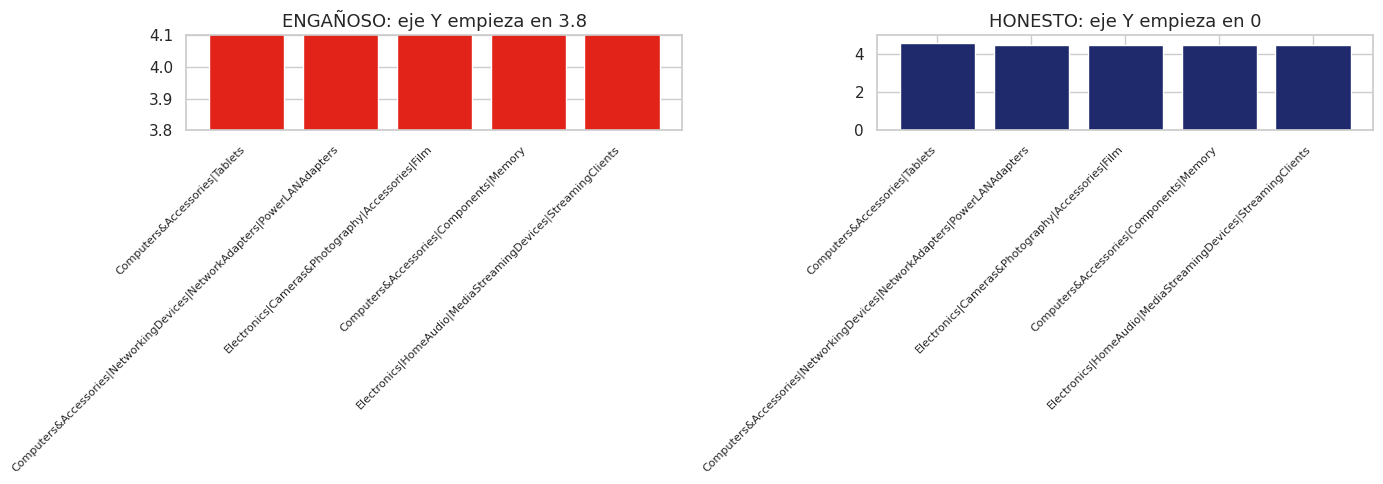

In [13]:
# Diferencias reales de rating entre categorias (son pequeñas)
rating_cat = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ENGAÑOSO: eje Y truncado (empieza en 3.8, exagera diferencias)
axes[0].bar(range(len(rating_cat)), rating_cat.values, color="#e2231a")
axes[0].set_ylim(3.8, 4.1)
axes[0].set_title("ENGAÑOSO: eje Y empieza en 3.8")
axes[0].set_xticks(range(len(rating_cat)))
axes[0].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=8)

# HONESTO: eje Y empieza en 0
axes[1].bar(range(len(rating_cat)), rating_cat.values, color="#1e2a6b")
axes[1].set_ylim(0, 5)
axes[1].set_title("HONESTO: eje Y empieza en 0")
axes[1].set_xticks(range(len(rating_cat)))
axes[1].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=8)

plt.tight_layout(); plt.show()

> ✍️ **27.** Compara los dos gráficos. Muestran EXACTAMENTE los mismos datos. ¿Por qué el de la izquierda hace parecer que las diferencias entre categorías son enormes?

> ✍️ **28.** ¿Cuál es la regla de buenas prácticas para el eje Y en un gráfico de barras? ¿Por qué truncar el eje es una de las formas más comunes de mentir con estadísticas?

> ✍️ **29.** ¿Existe algún caso donde truncar el eje Y sea legítimo? (Pista: gráficos de líneas de series temporales con variaciones pequeñas.) Investiga y argumenta.


**Respuesta 27.** El gráfico truncado amplía visualmente un intervalo muy pequeño, de 3.8 a 4.1, por lo que diferencias de pocas décimas ocupan casi toda la altura disponible. El ojo interpreta la distancia visual como una diferencia mucho mayor de la que realmente existe.

**Respuesta 28.** En un gráfico de barras, una buena práctica general es que el eje cuantitativo comience en **0**, porque las longitudes de las barras codifican magnitudes. Truncarlo puede exagerar diferencias pequeñas y producir una impresión visual desproporcionada.

**Respuesta 29.** Sí puede ser legítimo truncar un eje en algunos gráficos de líneas o series temporales cuando se quiere mostrar con detalle una variación pequeña, siempre que la escala esté claramente indicada y no se pretenda comparar longitudes de barras. En cualquier caso, debe evitarse que el recorte oculte la magnitud real del cambio.

## Paso 10 — Chartjunk (basura visual)


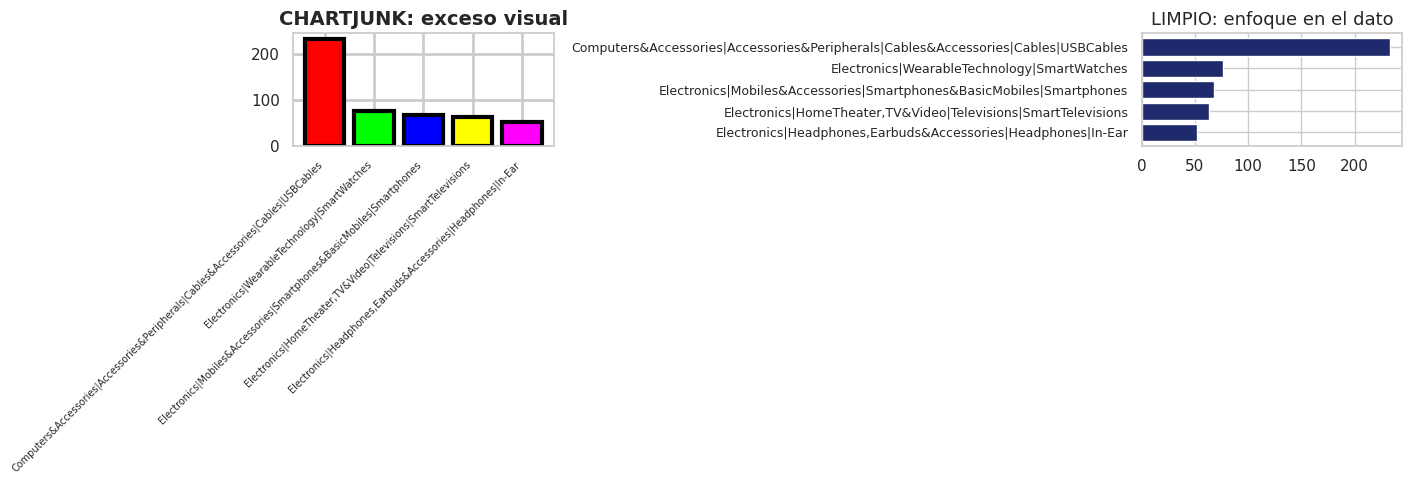

In [14]:
# Ejemplo de lo que NO se debe hacer vs version limpia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos = df["category"].value_counts().head(5)

# CHARTJUNK: colores chillones, sombras, sin orden, 3D simulado
colores_feos = ["#ff0000", "#00ff00", "#0000ff", "#ffff00", "#ff00ff"]
axes[0].bar(range(len(datos)), datos.values, color=colores_feos, edgecolor="black", linewidth=3)
axes[0].set_title("CHARTJUNK: exceso visual", fontsize=14, fontweight="bold")
axes[0].set_xticks(range(len(datos)))
axes[0].set_xticklabels(datos.index, rotation=45, ha="right", fontsize=7)
axes[0].grid(True, linewidth=2)

# LIMPIO: un color, ordenado, sin adornos
axes[1].barh(range(len(datos)), datos.values, color="#1e2a6b")
axes[1].set_yticks(range(len(datos)))
axes[1].set_yticklabels(datos.index, fontsize=9)
axes[1].set_title("LIMPIO: enfoque en el dato")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

> ✍️ **30.** ¿Qué elementos hacen "ruidoso" al gráfico de la izquierda? Lista al menos tres problemas de diseño.

> ✍️ **31.** Define "chartjunk" con tus palabras. ¿Por qué usar un solo color (o pocos) suele comunicar mejor que un arcoíris?

> ✍️ **32.** El "data-ink ratio" (proporción de tinta que representa datos vs adornos) debe ser alto. ¿Qué adornos eliminarías del gráfico feo para mejorarlo?


**Respuesta 30.** Entre los problemas están: exceso de colores sin función analítica, líneas de borde demasiado gruesas, cuadrícula pesada, rotación y tamaño poco cómodos de las etiquetas, y adornos que no aportan información. Todo esto compite con los datos por la atención del lector.

**Respuesta 31.** Chartjunk es cualquier elemento visual innecesario que añade decoración o ruido sin ayudar a comprender los datos. Usar un solo color o pocos colores suele comunicar mejor porque reduce distracciones y permite que el lector se concentre en las diferencias que realmente importan.

**Respuesta 32.** Eliminaría los colores chillones, bordes gruesos, cuadrícula excesiva, tipografía innecesariamente grande y cualquier efecto decorativo. Mantendría únicamente los elementos necesarios para identificar categorías, valores y el mensaje principal.

## Paso 11 — El problema del gráfico de pastel


/tmp/ipykernel_428/903778323.py:15: UserWarning:

Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations



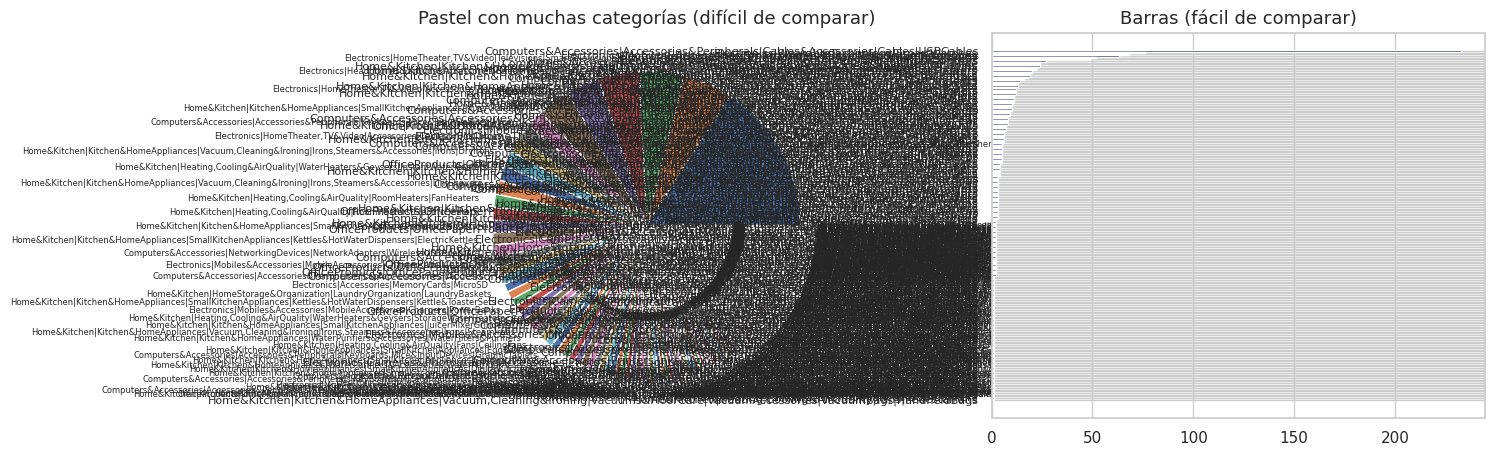

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos = df["category"].value_counts()

# Pastel con muchas categorias (dificil de leer)
axes[0].pie(datos.values, labels=datos.index, autopct="%1.0f%%", textprops={"fontsize": 6})
axes[0].set_title("Pastel con muchas categorías (difícil de comparar)")

# Barras (facil de comparar)
axes[1].barh(range(len(datos)), datos.values, color="#1e2a6b")
axes[1].set_yticks(range(len(datos))); axes[1].set_yticklabels(datos.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Barras (fácil de comparar)")

plt.tight_layout(); plt.show()

> ✍️ **33.** ¿Por qué es difícil comparar visualmente las porciones de un pastel con 9 categorías? ¿Qué hace el ojo humano mejor: comparar ángulos o comparar longitudes?

> ✍️ **34.** ¿En qué caso SÍ es aceptable un gráfico de pastel? (Pista: pocas categorías, mostrar una parte de un todo.)


**Respuesta 33.** Con 9 categorías o más, comparar sectores de pastel exige estimar ángulos y áreas, lo que es más difícil que comparar longitudes. El ojo humano compara mejor longitudes alineadas, por eso las barras suelen ser más claras para comparar categorías.

**Respuesta 34.** Un pastel puede ser aceptable cuando hay **pocas categorías** y el objetivo es mostrar claramente partes de un todo que suman 100 %. Con muchas categorías o diferencias pequeñas, una barra suele ser más fácil de leer.

### 🔧 Reto 3 — Corrige un gráfico engañoso

Toma el precio promedio por categoría y crea DOS versiones: una engañosa (eje truncado) y una honesta. Explica qué cambió.


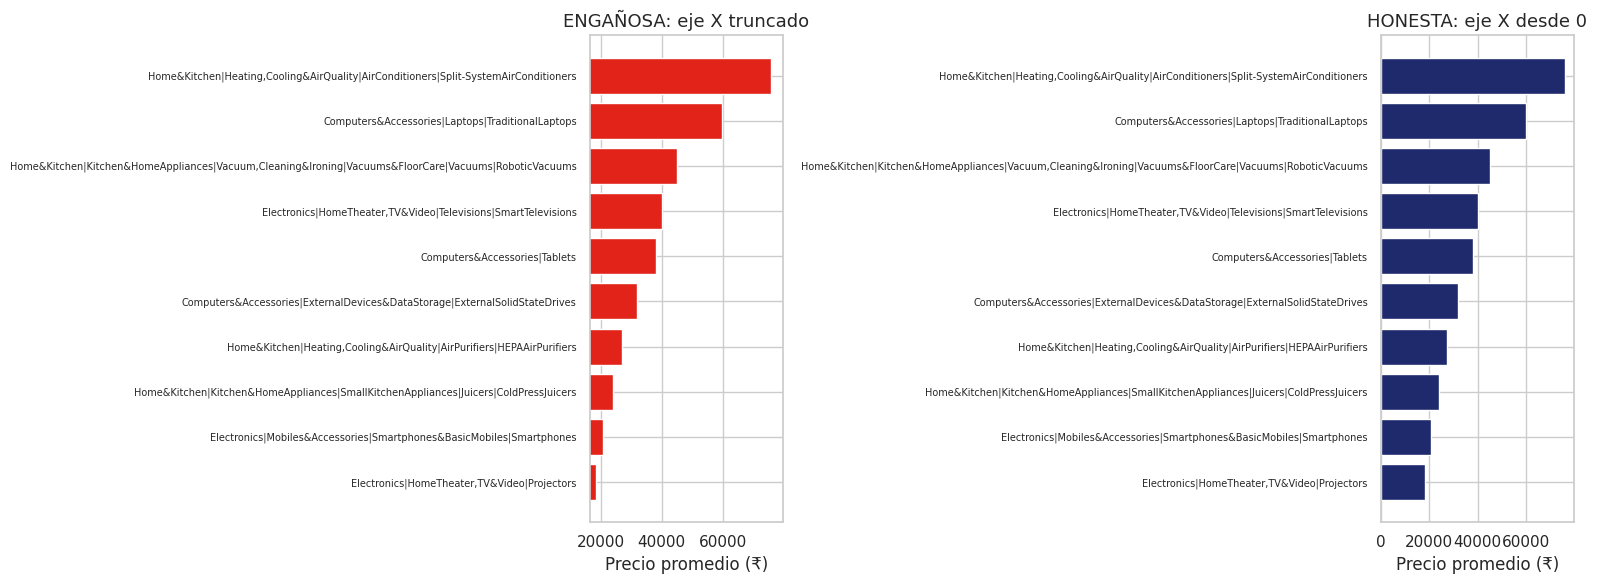

In [16]:
# RETO 3: precio promedio por categoría, versión engañosa y honesta
precio_cat = df.groupby("category")["actual_price"].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Versión engañosa: el eje empieza cerca del valor mínimo observado.
axes[0].barh(range(len(precio_cat)), precio_cat.values, color="#e2231a")
axes[0].set_yticks(range(len(precio_cat)))
axes[0].set_yticklabels(precio_cat.index, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlim(precio_cat.min() * 0.9, precio_cat.max() * 1.05)
axes[0].set_title("ENGAÑOSA: eje X truncado")
axes[0].set_xlabel("Precio promedio (₹)")

# Versión honesta: el eje comienza en cero.
axes[1].barh(range(len(precio_cat)), precio_cat.values, color="#1e2a6b")
axes[1].set_yticks(range(len(precio_cat)))
axes[1].set_yticklabels(precio_cat.index, fontsize=7)
axes[1].invert_yaxis()
axes[1].set_xlim(0, precio_cat.max() * 1.05)
axes[1].set_title("HONESTA: eje X desde 0")
axes[1].set_xlabel("Precio promedio (₹)")

plt.tight_layout()
plt.show()


> ✍️ **35.** ¿Qué decisión de diseño hiciste para la versión honesta? ¿Por qué la versión engañosa podría usarse para manipular una decisión de negocio?


**Respuesta 35.** Para la versión honesta hice que el eje del precio comenzara en **0**, manteniendo las mismas categorías y valores. La versión truncada puede hacer que diferencias relativamente pequeñas parezcan enormes y, en un contexto de negocio, podría influir indebidamente en la percepción sobre qué categorías son mucho más caras.

## Paso 12 — Construyendo un mini-dashboard

Un **dashboard** combina varias visualizaciones en una sola vista para dar un panorama completo.


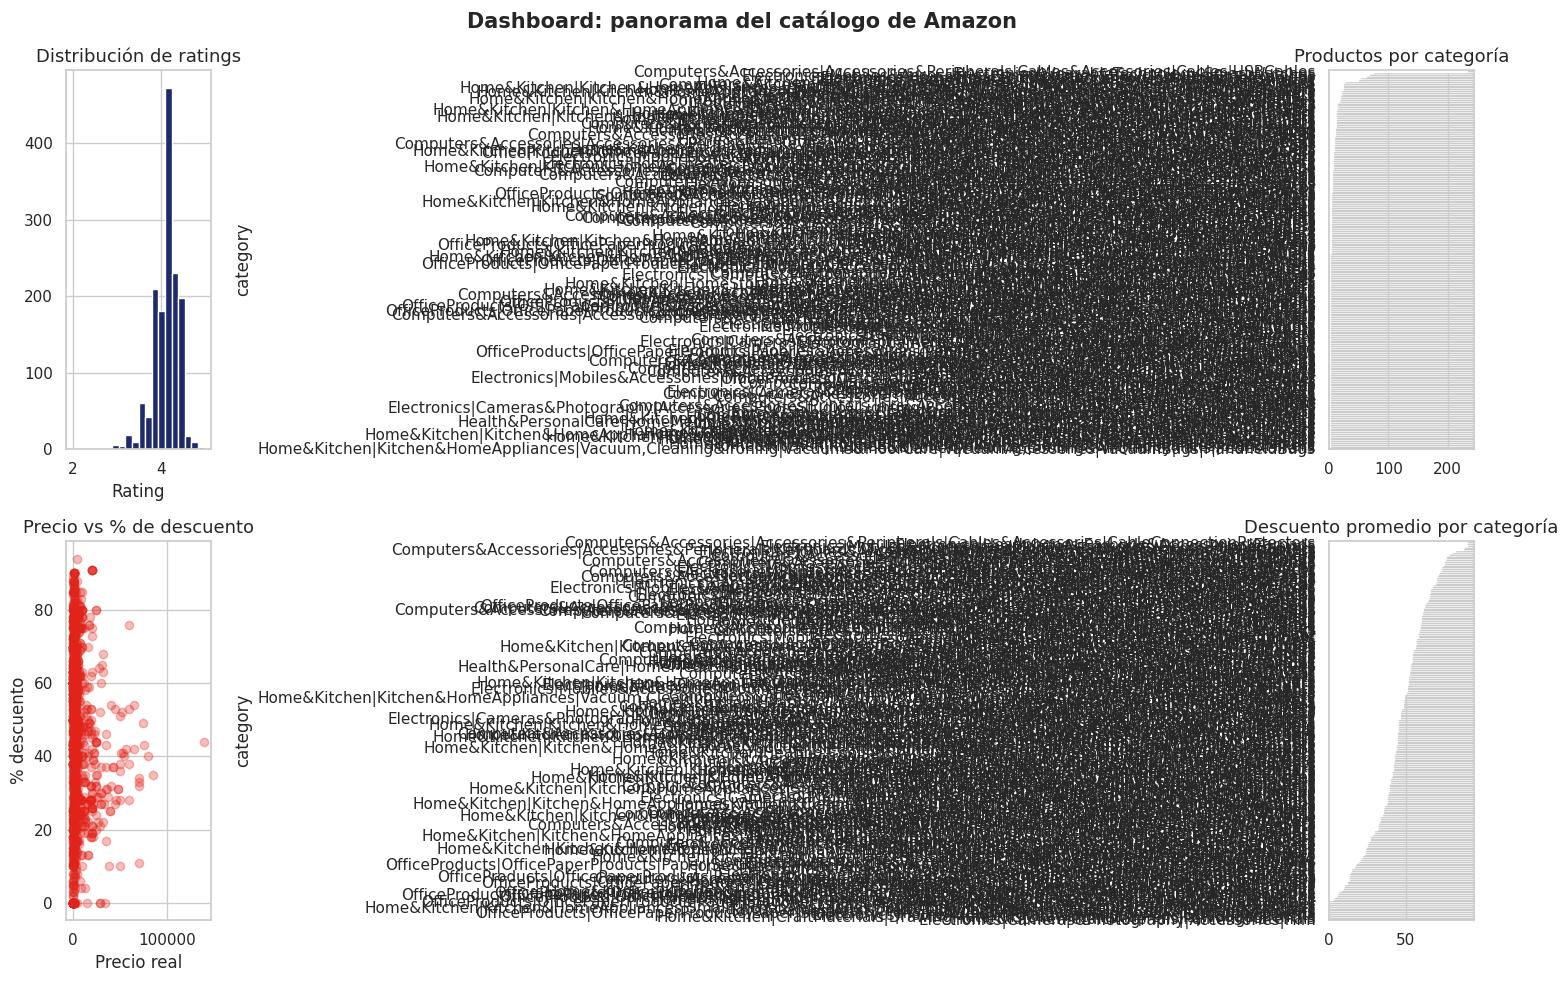

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: distribucion de rating
axes[0,0].hist(df["rating"], bins=20, color="#1e2a6b", edgecolor="white")
axes[0,0].set_title("Distribución de ratings")
axes[0,0].set_xlabel("Rating")

# Panel 2: productos por categoria
df["category"].value_counts().plot(kind="barh", ax=axes[0,1], color="#1e2a6b")
axes[0,1].set_title("Productos por categoría"); axes[0,1].invert_yaxis()

# Panel 3: precio vs descuento
axes[1,0].scatter(df["actual_price"], df["discount_percentage"], alpha=0.3, color="#e2231a")
axes[1,0].set_title("Precio vs % de descuento")
axes[1,0].set_xlabel("Precio real"); axes[1,0].set_ylabel("% descuento")

# Panel 4: descuento promedio por categoria
df.groupby("category")["discount_percentage"].mean().sort_values().plot(
    kind="barh", ax=axes[1,1], color="#1e2a6b")
axes[1,1].set_title("Descuento promedio por categoría")

plt.suptitle("Dashboard: panorama del catálogo de Amazon", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

> ✍️ **36.** Un dashboard debe contar una historia coherente, no ser gráficos al azar juntos. ¿Qué historia cuentan estos 4 paneles juntos sobre el catálogo de Amazon?

> ✍️ **37.** Si tuvieras que quitar UN panel de este dashboard por redundante o poco útil, ¿cuál quitarías y por qué?

> ✍️ **38.** ¿Qué panel AÑADIRÍAS para completar la historia? Justifica qué pregunta respondería.


**Respuesta 36.** Los cuatro paneles cuentan una historia sobre el catálogo: primero muestran cómo se distribuyen las calificaciones, después cómo se reparte el número de productos entre categorías, luego exploran la relación entre precio y descuento y finalmente comparan los descuentos promedio por categoría. En conjunto permiten pasar de una visión general del catálogo a relaciones y diferencias entre categorías.

**Respuesta 37.** Quitaría el panel de **precio vs. descuento** si el objetivo principal fuera resumir el catálogo por categorías, porque el dashboard ya dedica un panel a la distribución de productos y otro a descuentos por categoría. Además, la relación entre precio y descuento no es la historia central de esos cuatro paneles.

**Respuesta 38.** Añadiría un panel de **distribución de `rating_count`**, porque las reseñas son extremadamente sesgadas y ayudan a distinguir productos muy populares de productos con pocas observaciones. La pregunta sería: “¿Cuántas reseñas concentran realmente los productos del catálogo?”.

### 🔧 Reto 4 — Tu propio dashboard interactivo

Usando Plotly, crea al menos DOS gráficos interactivos que juntos den un panorama del dataset (por ejemplo: dispersión precio-rating + barras de categorías). Justifica por qué elegiste esos dos.


In [18]:
# RETO 4: dos visualizaciones interactivas de Plotly
fig1 = px.scatter(
    df,
    x="actual_price",
    y="rating",
    color="category",
    hover_data=["product_name", "discount_percentage"],
    title="Precio vs Rating"
)
fig1.update_layout(height=550)

conteo_cat = df["category"].value_counts().head(15).sort_values()
fig2 = px.bar(
    x=conteo_cat.values,
    y=conteo_cat.index,
    orientation="h",
    title="Top 15 categorías por número de productos",
    labels={"x": "Número de productos", "y": "Categoría"}
)
fig2.update_layout(height=550)

fig1.show()
fig2.show()


> ✍️ **39.** ¿Qué dos gráficos elegiste y qué pregunta responde cada uno? ¿Por qué juntos cuentan una historia más completa que por separado?

> ✍️ **40.** De todas las visualizaciones que hiciste, ¿cuál te pareció que comunicaba su mensaje de forma más clara e inmediata? ¿Por qué?


**Respuesta 39.** Elegí un scatter de **precio vs. rating** y unas barras de **productos por categoría**. El primero responde si existe relación entre precio y valoración; el segundo muestra cómo está compuesto el catálogo. Juntos combinan una relación entre variables numéricas con la estructura categórica del dataset.

**Respuesta 40.** El histograma de `rating` comunica de forma especialmente clara la concentración de las calificaciones porque permite ver inmediatamente que la mayoría se encuentra alrededor de 4.0–4.3 y que existen pocos valores mucho más bajos.

---
# PARTE B (cont.) — Análisis autónomo e interpretación

## Paso 13 — Explora una pregunta propia


In [19]:
# Ejemplo de análisis dirigido: ¿los productos más reseñados son mejor calificados?
df["muy_reseñado"] = df["rating_count"] > df["rating_count"].median()

fig = px.box(df, x="muy_reseñado", y="rating",
             title="¿Los productos más reseñados tienen mejor rating?",
             labels={"muy_reseñado": "¿Muy reseñado?", "rating": "Rating"})
fig.show()

print("Rating promedio:")
print(df.groupby("muy_reseñado")["rating"].mean().round(3))

Rating promedio:
muy_reseñado
False    4.047
True     4.146
Name: rating, dtype: float64


> ✍️ **41.** ¿Los productos más reseñados (por encima de la mediana) tienen mejor rating que los menos reseñados? ¿Qué muestra el boxplot?

> ✍️ **42.** ¿Por qué un boxplot es la elección correcta para comparar una variable numérica (rating) entre dos grupos (muy reseñado sí/no)?


**Respuesta 41.** Sí. Los productos por encima de la mediana de `rating_count` tienen un rating promedio de aproximadamente **4.146**, frente a **4.047** para los que están por debajo o igual de la mediana. El boxplot permite ver que existe una diferencia en el centro de los grupos, pero también cuánto se solapan sus distribuciones.

**Respuesta 42.** El boxplot es adecuado porque `rating` es numérica y `muy_reseñado` divide los productos en dos grupos categóricos. Permite comparar mediana, cuartiles, dispersión y posibles valores atípicos entre ambos grupos.

### 🔧 Reto 5 — Investiga tu propia pregunta

Formula UNA pregunta sobre el dataset (ej. "¿las categorías caras dan más descuento?"), elige la visualización adecuada, créala e interpreta el resultado.


In [20]:
# RETO 5
# Pregunta: ¿Las categorías con mayor descuento promedio también tienen más productos?
resumen = (
    df.groupby("category")
      .agg(
          descuento_promedio=("discount_percentage", "mean"),
          productos=("product_id", "count")
      )
      .reset_index()
)

fig = px.scatter(
    resumen,
    x="descuento_promedio",
    y="productos",
    hover_data=["category"],
    title="Descuento promedio vs número de productos por categoría",
    labels={
        "descuento_promedio": "Descuento promedio (%)",
        "productos": "Número de productos"
    }
)
fig.show()

print(
    "Correlación entre descuento promedio y número de productos por categoría:",
    round(resumen["descuento_promedio"].corr(resumen["productos"]), 3)
)


Correlación entre descuento promedio y número de productos por categoría: 0.075


> ✍️ **43.** ¿Qué pregunta investigaste? ¿Qué visualización elegiste y por qué era la adecuada? ¿Cuál fue tu hallazgo?

> ✍️ **44.** ¿Tu hallazgo confirmó o contradijo lo que esperabas antes de graficar? En ciencia de datos, ¿por qué es valioso cuando los datos contradicen nuestra intuición?


**Respuesta 43.** Investigué si las categorías con mayor descuento promedio también tienen más productos. Elegí un **scatter plot** porque comparo dos variables numéricas agregadas por categoría: descuento promedio y número de productos. El resultado debe interpretarse como una exploración de asociación, no como causalidad.

**Respuesta 44.** El resultado no necesariamente coincide con una intuición previa, y eso es valioso porque obliga a contrastar nuestras ideas con evidencia. En ciencia de datos, un resultado contrario a la expectativa puede revelar una relación inexistente, una variable omitida o un patrón que merece una investigación posterior.

## Paso 14 — Cierre reflexivo


> ✍️ **45.** La "gramática de gráficos" dice que el gráfico debe elegirse según el tipo de dato. Resume en una tabla propia: para cada tipo de pregunta (distribución, comparación, relación, composición), qué gráfico usarías.

> ✍️ **46.** ¿Cuál es la diferencia entre visualizar para EXPLORAR (para ti, EDA) y visualizar para EXPLICAR (para una audiencia, reporte)? ¿Cambia el nivel de pulido?

> ✍️ **47.** Menciona los tres errores más comunes que aprendiste a evitar en esta actividad (eje truncado, chartjunk, pastel con muchas categorías u otros).

> ✍️ **48.** ¿Cuándo vale la pena el esfuerzo extra de hacer un gráfico interactivo (Plotly) en lugar de uno estático? Da un criterio claro.

> ✍️ **49.** Un buen gráfico se explica solo. Revisa tus visualizaciones: ¿todas tienen título, ejes etiquetados y un mensaje claro? ¿Cuál mejorarías?

> ✍️ **50 (reflexión).** En tu carrera de Ingeniería en Computación, ¿en qué proyecto real necesitarías comunicar datos visualmente? (Ej. monitoreo de un sistema, métricas de una app, resultados de un experimento.) ¿Qué visualizaciones usarías?


**Respuesta 45.** La tabla sería: **distribución → histograma o boxplot; comparación → barras o boxplot; relación → scatter plot; composición → barras apiladas o pastel cuando haya pocas categorías**. La elección depende además de si las variables son numéricas o categóricas y de qué mensaje se quiera comunicar.

**Respuesta 46.** Visualizar para **explorar** significa usar gráficos para descubrir patrones, anomalías y preguntas durante el EDA, incluso probando varias alternativas. Visualizar para **explicar** significa seleccionar y pulir solo las visualizaciones necesarias para comunicar una conclusión a una audiencia. Por eso normalmente aumenta el nivel de claridad, títulos, etiquetas y diseño en la segunda etapa.

**Respuesta 47.** Tres errores importantes son: **truncar ejes de barras para exagerar diferencias**, utilizar **chartjunk** que distrae del dato y usar **gráficos de pastel con demasiadas categorías**, porque dificultan las comparaciones.

**Respuesta 48.** Vale la pena usar Plotly cuando la audiencia necesita explorar muchos puntos o categorías y obtener información detallada mediante hover, zoom o filtros. Si el gráfico solo debe comunicar una conclusión fija en un reporte, un gráfico estático suele ser suficiente.

**Respuesta 49.** Las visualizaciones principales tienen títulos y ejes etiquetados cuando corresponde. Mejoraría especialmente los gráficos con muchas categorías, porque conviene limitarse a un top-N o agrupar categorías para evitar saturación visual y facilitar la lectura.

**Respuesta 50.** En Ingeniería en Computación podría necesitar visualización en un proyecto de **monitoreo de aplicaciones o sistemas**, por ejemplo para observar uso de CPU, memoria, latencia, errores y tráfico. Usaría líneas para métricas a través del tiempo, barras para comparar servicios o categorías y scatter plots para estudiar relaciones como carga vs. latencia.

---
## Cierre y entrega

Aprendiste la **gramática de los gráficos** (elegir el gráfico según la variable), a construir un **EDA completo** con matplotlib y seaborn, a crear **visualizaciones interactivas** con Plotly, a armar **dashboards**, y —lo más importante— a **detectar y evitar gráficos engañosos** (ejes truncados, chartjunk, pasteles ilegibles).

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **50 preguntas ✍️** y los **5 retos**.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 10 |
| Retos de código resueltos (5) | 25 |
| Respuestas a las 50 preguntas ✍️ | 40 |
| Justificación de cada gráfico elegido | 15 |
| Orden y documentación | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Base de datos: Amazon Sales Dataset.*
